<a href="https://colab.research.google.com/github/Debarati-Das-hub/Debarati-Das-hub.github.io/blob/main/CropRecom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

%pip install lime shap --quiet
print('All libraries installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 17.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
All libraries installed.


In [ ]:
%pip install lime shap --quiet
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import lime
import lime.lime_tabular
import shap

print('All libraries imported.')

All libraries imported.


In [ ]:
from google.colab import files
import io

print('uploading Crop_recommendation.csv file...')
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head(10)

uploading Crop_recommendation.csv file...


Saving Crop_recommendation[1].csv to Crop_recommendation[1].csv
Dataset loaded successfully!
Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [ ]:
print(' Dataset Info ')
print(df.info())
print('\n  Statistical Summary  ')
print(df.describe())
print('\n Missing Values ')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print(f'Total unique crops: {df["label"].nunique()}')
print('Crops:', df['label'].unique())

 Dataset Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

  Statistical Summary  
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.25804

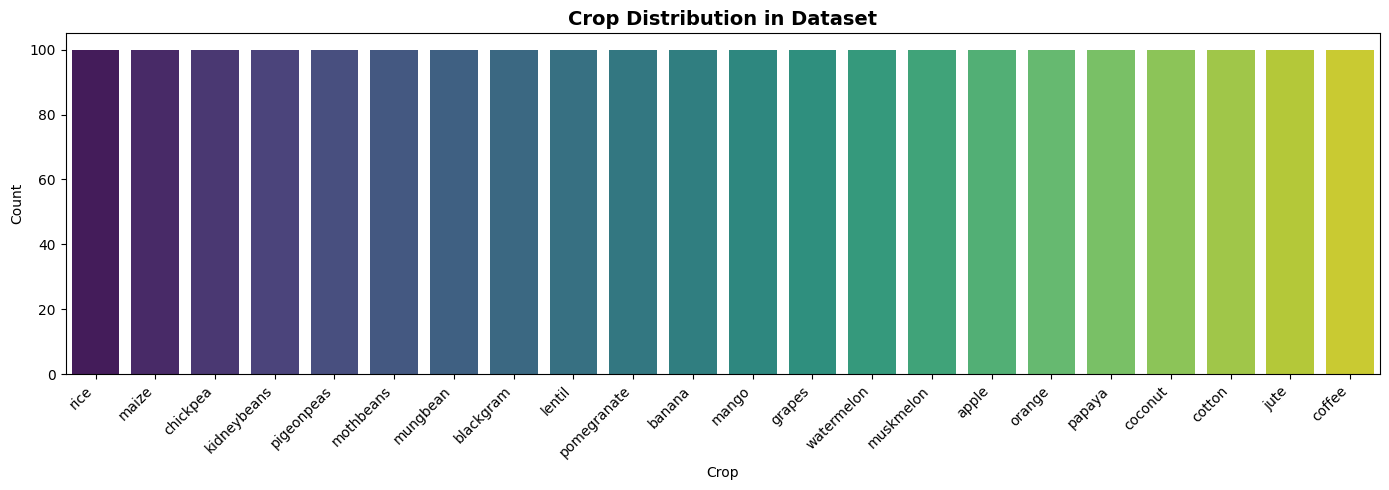

In [ ]:
plt.figure(figsize=(14, 5))
crop_counts = df['label'].value_counts()
sns.barplot(x=crop_counts.index, y=crop_counts.values, palette='viridis')
plt.title('Crop Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

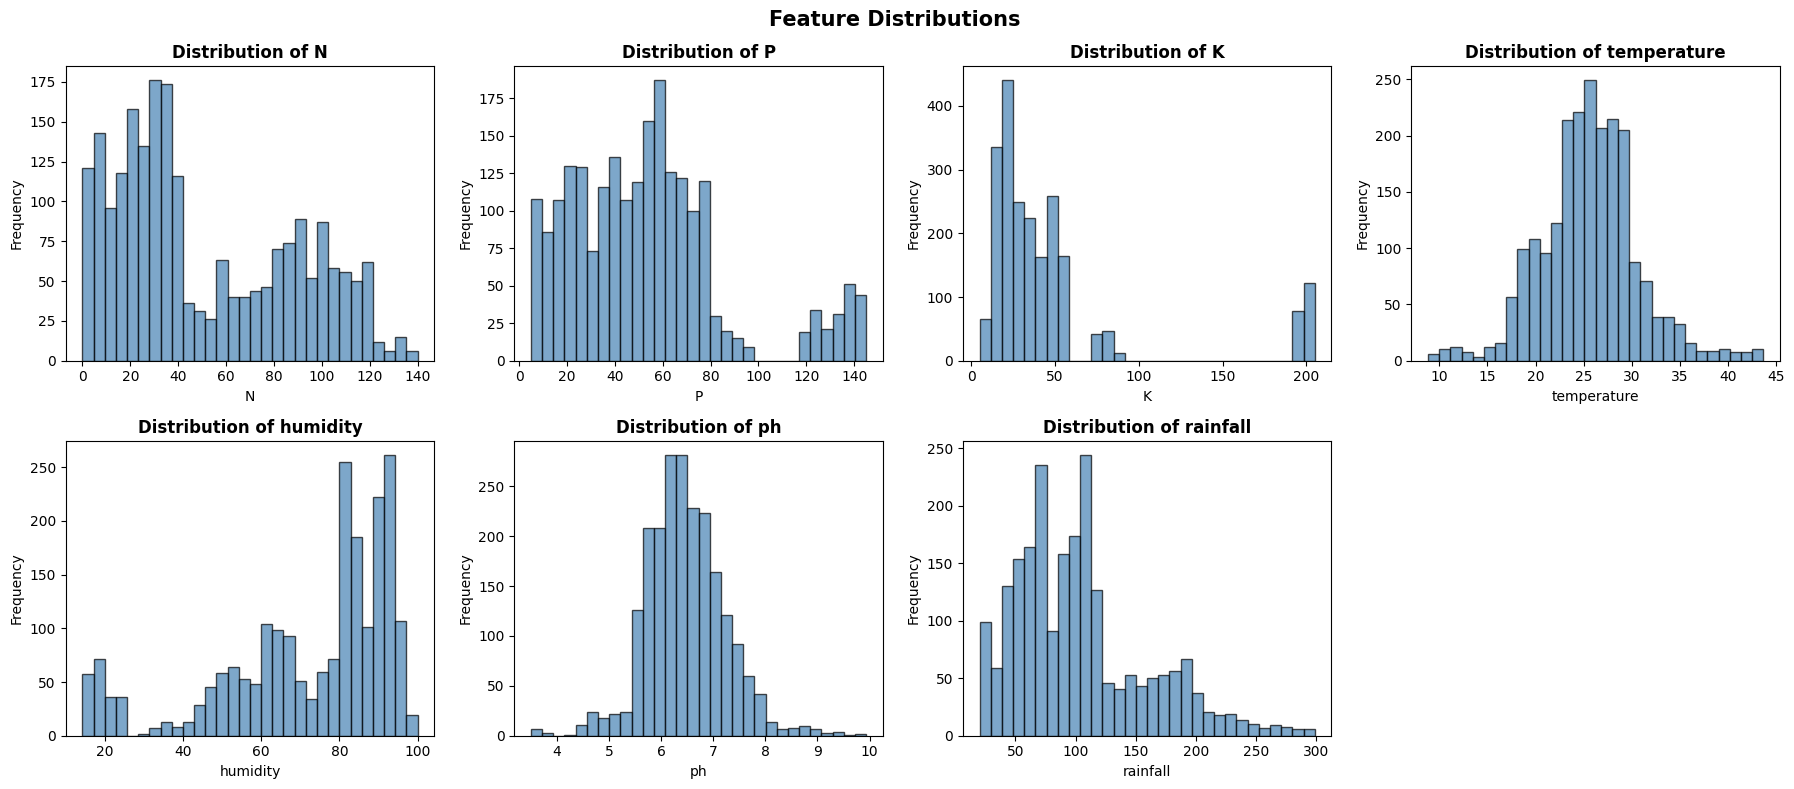

In [ ]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {feature}', fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')
plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

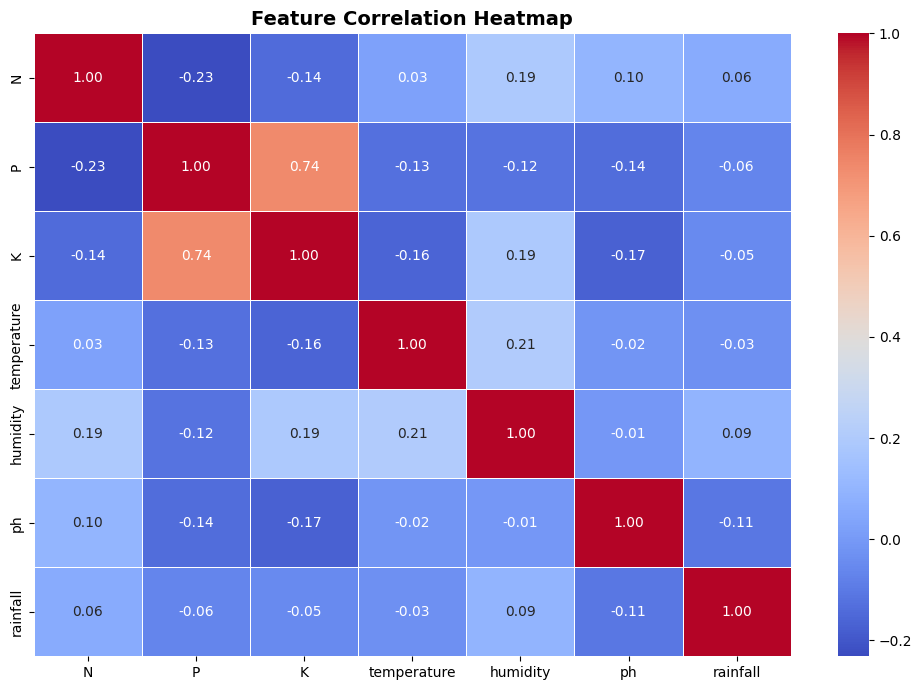

In [ ]:
plt.figure(figsize=(10, 7))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Handling missing values
for col in features:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Removing duplicates
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Removed {before - after} duplicate rows.')

# Encoding labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])
print('\nLabel Encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {i:2d} -> {cls}')

# Spliting features and target
X = df[features]
y = df['label_encoded']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print('\n Preprocessing complete!')

Removed 0 duplicate rows.

Label Encoding:
   0 -> apple
   1 -> banana
   2 -> blackgram
   3 -> chickpea
   4 -> coconut
   5 -> coffee
   6 -> cotton
   7 -> grapes
   8 -> jute
   9 -> kidneybeans
  10 -> lentil
  11 -> maize
  12 -> mango
  13 -> mothbeans
  14 -> mungbean
  15 -> muskmelon
  16 -> orange
  17 -> papaya
  18 -> pigeonpeas
  19 -> pomegranate
  20 -> rice
  21 -> watermelon

Training set: 1760 samples
Test set:     440 samples

 Preprocessing complete!


In [ ]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN':           KNeighborsClassifier(n_neighbors=5),
    'SVM':           SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes':   GaussianNB()
}

results = {}

for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall':    recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1':        f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'cv_mean':   cv_scores.mean(),
        'cv_std':    cv_scores.std()
    }
    print(f' Accuracy: {results[name]["accuracy"]:.4f}')

print('\n Models trained.')

Training Decision Tree...  Accuracy: 0.9795
Training Random Forest...  Accuracy: 0.9955
Training KNN...  Accuracy: 0.9795
Training SVM...  Accuracy: 0.9841
Training Naive Bayes...  Accuracy: 0.9955

 Models trained.


In [ ]:
metrics_df = pd.DataFrame({
    'Model':     list(results.keys()),
    'Accuracy':  [results[m]['accuracy']  for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall':    [results[m]['recall']    for m in results],
    'F1-Score':  [results[m]['f1']        for m in results],
    'CV Mean':   [results[m]['cv_mean']   for m in results],
    'CV Std':    [results[m]['cv_std']    for m in results],
})

metrics_df = metrics_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print('Model Performance Comparison')
print(metrics_df.round(4).to_string(index=False))

best_model_name = metrics_df.iloc[0]['Model']
print(f'\n Best Model: {best_model_name}')

Model Performance Comparison
        Model  Accuracy  Precision  Recall  F1-Score  CV Mean  CV Std
Random Forest    0.9955     0.9957  0.9955    0.9955   0.9950  0.0036
  Naive Bayes    0.9955     0.9959  0.9955    0.9954   0.9950  0.0022
          SVM    0.9841     0.9856  0.9841    0.9840   0.9823  0.0017
Decision Tree    0.9795     0.9806  0.9795    0.9794   0.9868  0.0033
          KNN    0.9795     0.9804  0.9795    0.9793   0.9714  0.0059

 Best Model: Random Forest


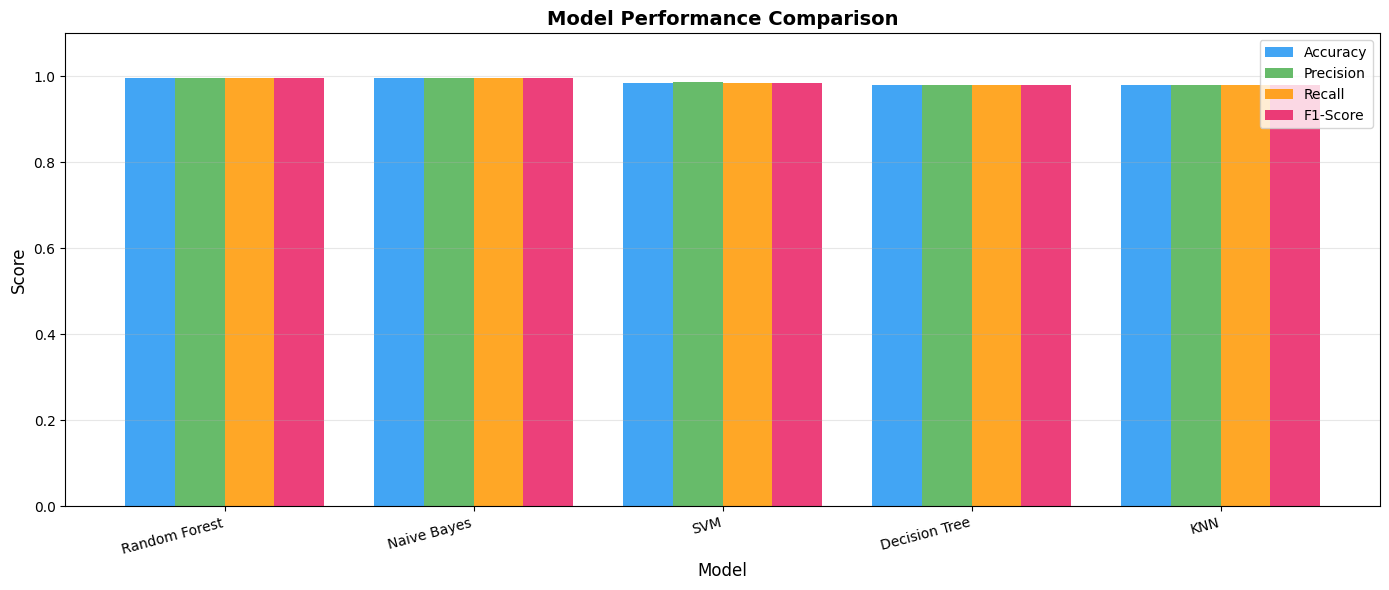

In [ ]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_df))
width = 0.2
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metric_cols, colors)):
    ax.bar(x + i * width, metrics_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

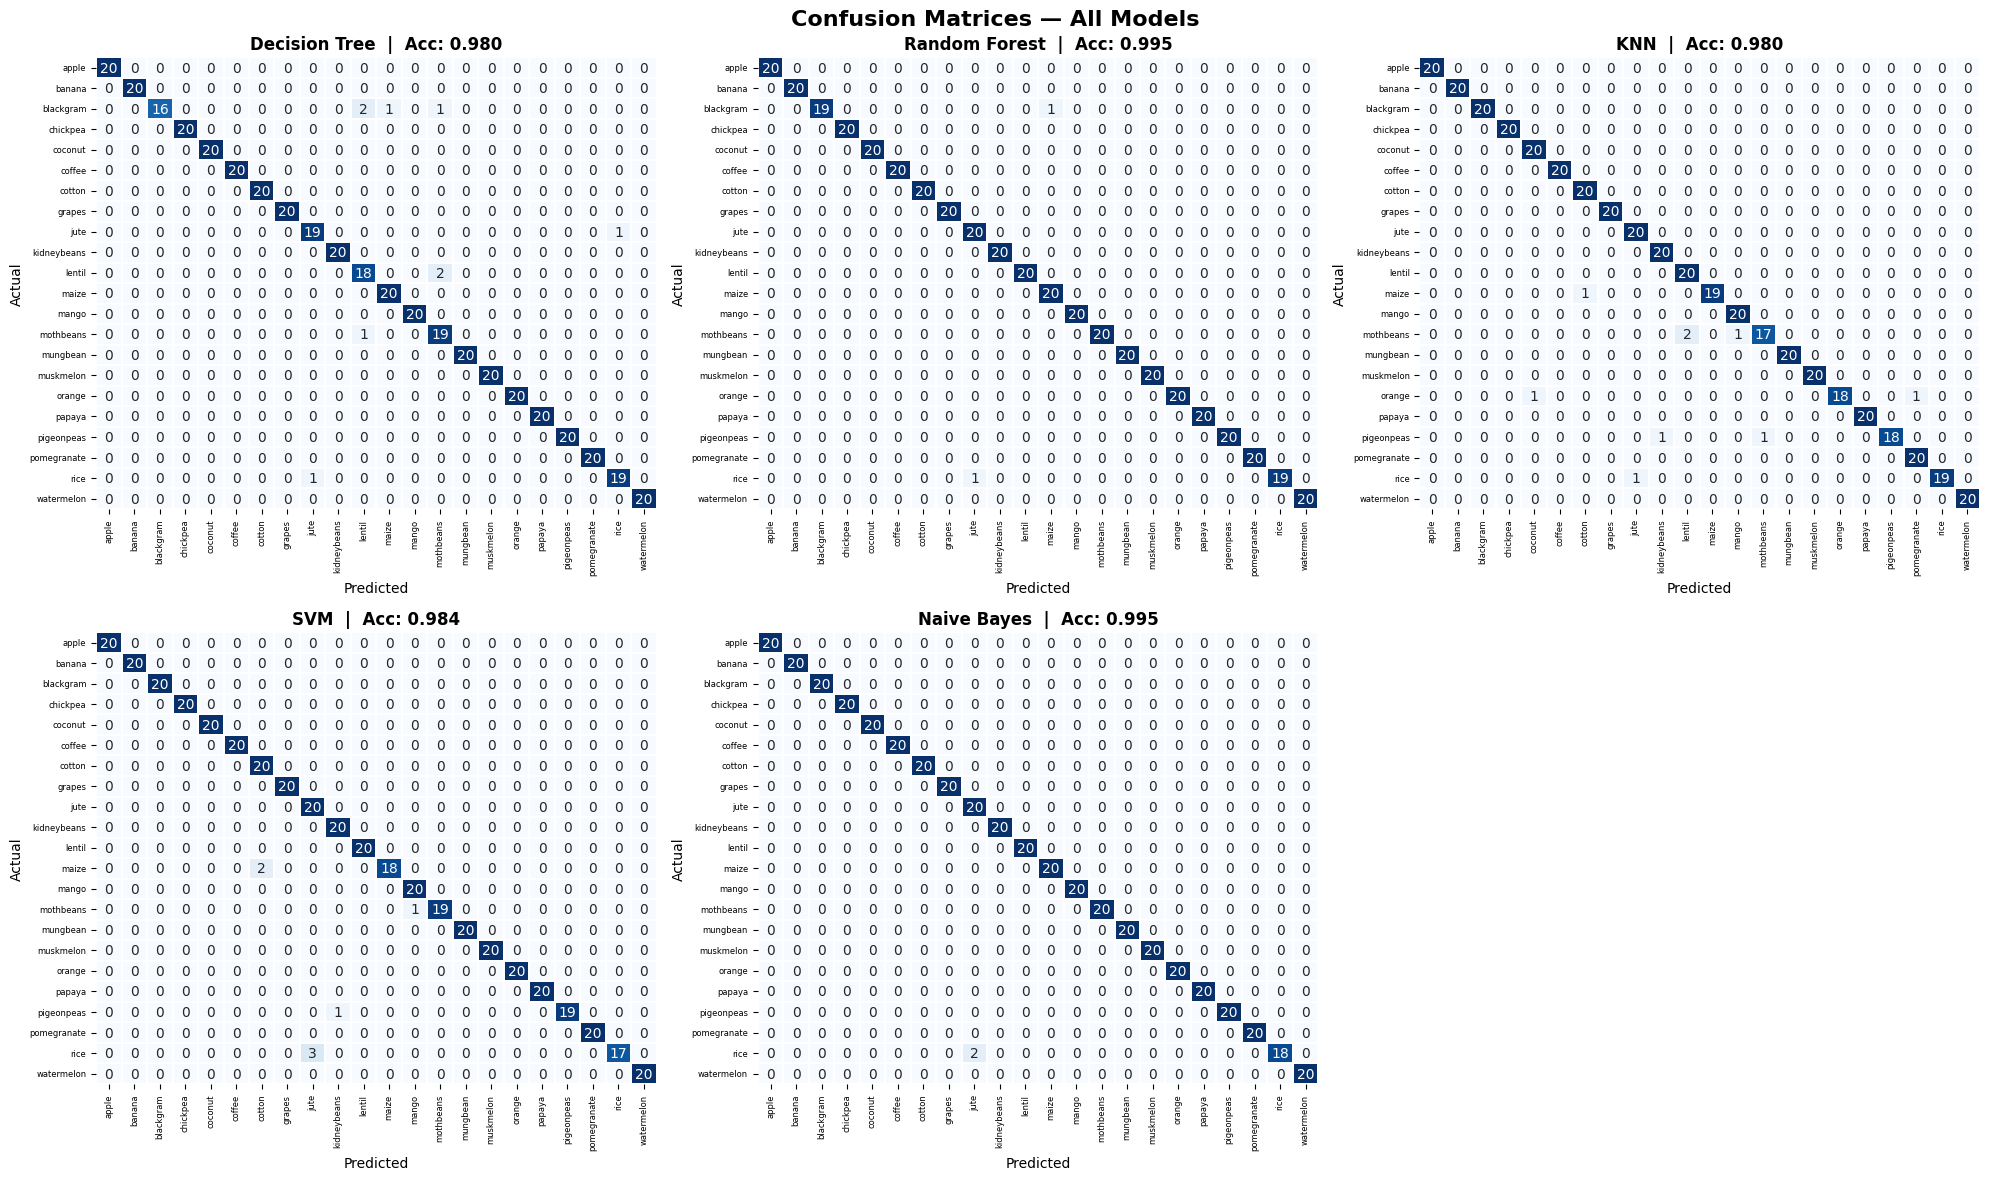

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
crop_labels = le.classes_

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=crop_labels, yticklabels=crop_labels,
        ax=axes[i], linewidths=0.3, cbar=False
    )
    axes[i].set_title(f'{name}  |  Acc: {res["accuracy"]:.3f}', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].tick_params(axis='x', rotation=90, labelsize=6)
    axes[i].tick_params(axis='y', labelsize=6)

axes[-1].axis('off')
plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

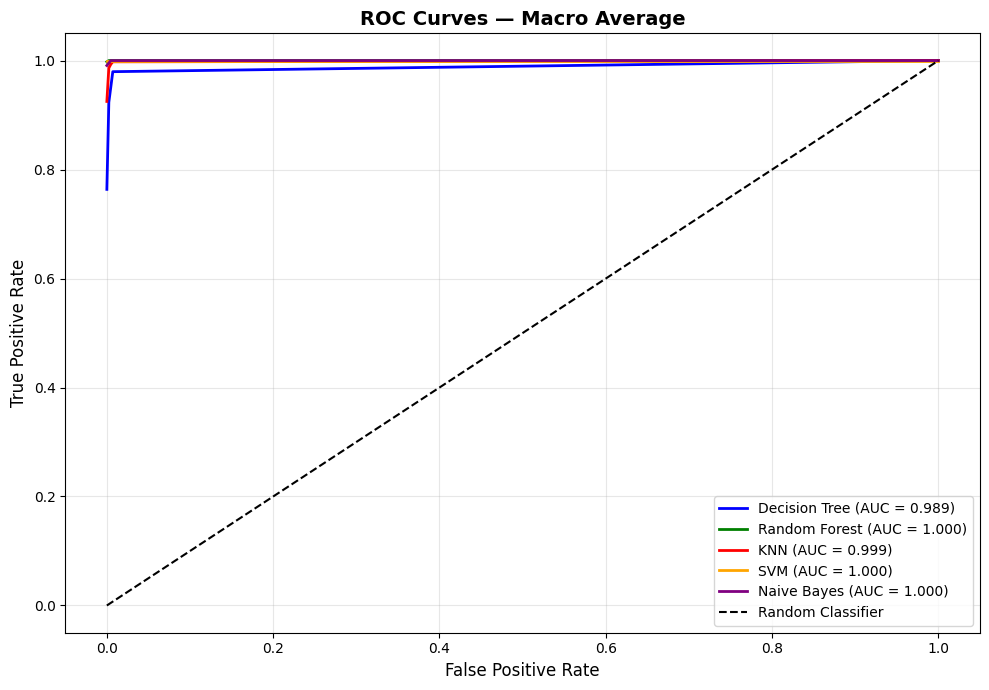

In [ ]:
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

plt.figure(figsize=(10, 7))
colors_roc = ['blue', 'green', 'red', 'orange', 'purple']

for (name, res), color in zip(results.items(), colors_roc):
    model = res['model']
    y_score = model.predict_proba(X_test)

    fpr_all, tpr_all = {}, {}
    for c in range(n_classes):
        fpr_all[c], tpr_all[c], _ = roc_curve(y_test_bin[:, c], y_score[:, c])

    all_fpr = np.unique(np.concatenate([fpr_all[c] for c in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_all[c], tpr_all[c])
    mean_tpr /= n_classes
    roc_auc = auc(all_fpr, mean_tpr)

    plt.plot(all_fpr, mean_tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Macro Average', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

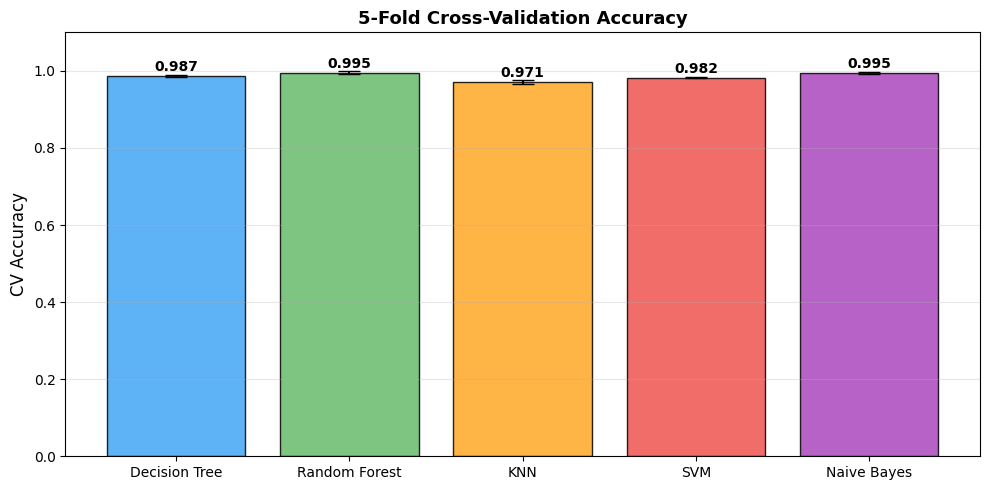

In [ ]:
plt.figure(figsize=(10, 5))
cv_means = [results[m]['cv_mean'] for m in results]
cv_stds  = [results[m]['cv_std']  for m in results]
model_names = list(results.keys())

bars = plt.bar(model_names, cv_means, yerr=cv_stds, capsize=8,
               color=['#42A5F5','#66BB6A','#FFA726','#EF5350','#AB47BC'],
               alpha=0.85, edgecolor='black')

for bar, mean in zip(bars, cv_means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('CV Accuracy', fontsize=12)
plt.title('5-Fold Cross-Validation Accuracy', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
best_model = results[best_model_name]['model']
best_pred  = results[best_model_name]['y_pred']

print(f'Classification Report: {best_model_name} ')
print(classification_report(y_test, best_pred, target_names=le.classes_))

Classification Report: Random Forest 
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00

In [ ]:
param_grids = {
    'Random Forest': {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]},
    'Decision Tree': {'max_depth': [None, 10, 20], 'criterion': ['gini', 'entropy']},
    'KNN':           {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']},
    'SVM':           {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']},
    'Naive Bayes':   {'var_smoothing': [1e-9, 1e-8, 1e-7]}
}

param_grid = param_grids.get(best_model_name, {})

gs = GridSearchCV(
    results[best_model_name]['model'].__class__(),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)

print(f'Best Parameters: {gs.best_params_}')
print(f'Best CV Accuracy:  {gs.best_score_:.4f}')

tuned_pred = gs.best_estimator_.predict(X_test)
print(f'Tuned Test Accuracy: {accuracy_score(y_test, tuned_pred):.4f}')
print(f'Tuned Test F1-Score: {f1_score(y_test, tuned_pred, average="weighted"):.4f}')

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Parameters: {'max_depth': 20, 'n_estimators': 50}
Best CV Accuracy:  0.9955
Tuned Test Accuracy: 0.9977
Tuned Test F1-Score: 0.9977


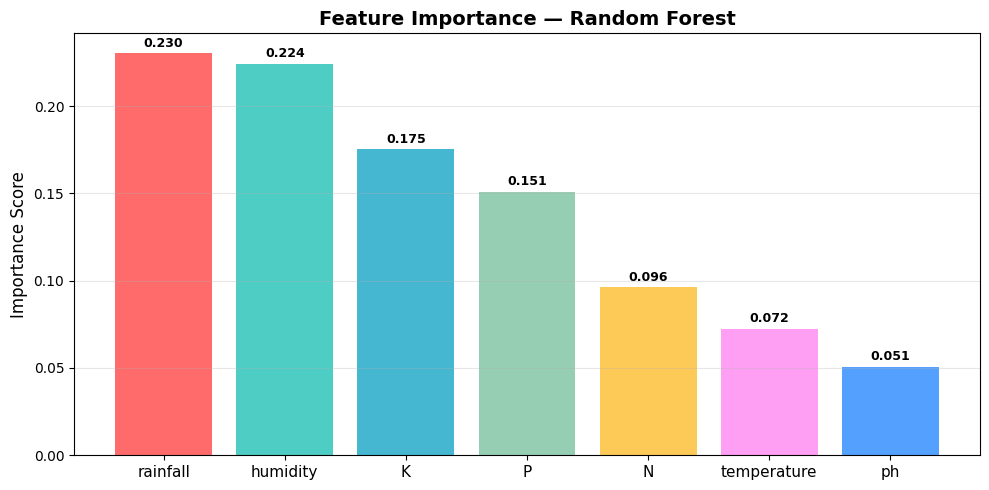

In [ ]:
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
colors_fi = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FECA57','#FF9FF3','#54A0FF']
bars = plt.bar(range(len(features)), importances[sorted_idx], color=colors_fi)
plt.xticks(range(len(features)), [features[i] for i in sorted_idx], fontsize=11)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Importance Score', fontsize=12)

for bar, score in zip(bars, importances[sorted_idx]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{score:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=features,
    class_names=le.classes_,
    discretize_continuous=True
)

sample_idx = 0
sample = X_test.iloc[sample_idx].values
actual_label    = le.classes_[y_test.iloc[sample_idx]]
predicted_label = le.classes_[results['Random Forest']['y_pred'][sample_idx]]

print(f'Actual Crop:    {actual_label}')
print(f'Predicted Crop: {predicted_label}')

exp = explainer.explain_instance(sample, rf_model.predict_proba, num_features=7, top_labels=1)
exp.show_in_notebook(show_table=True)

Actual Crop:    orange
Predicted Crop: orange


Computing SHAP values...
 SHAP values computed!


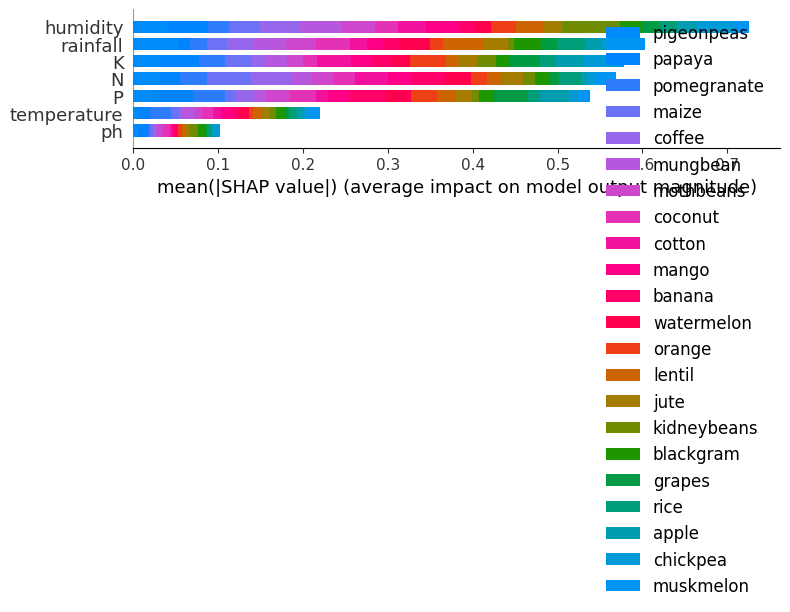

In [ ]:
print('Computing SHAP values...')
shap_explainer = shap.TreeExplainer(rf_model)
shap_values = shap_explainer.shap_values(X_test)
print(' SHAP values computed!')

shap.summary_plot(shap_values, X_test, feature_names=features,
                  plot_type='bar', class_names=le.classes_, show=True)

In [ ]:
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):
    input_data = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    input_scaled = scaler.transform(input_data)

    model = results['Random Forest']['model']
    pred_encoded = model.predict(input_scaled)[0]
    pred_proba   = model.predict_proba(input_scaled)[0]

    recommended_crop = le.classes_[pred_encoded]
    confidence = pred_proba[pred_encoded] * 100

    top3_idx = np.argsort(pred_proba)[::-1][:3]
    top3 = [(le.classes_[i], pred_proba[i]*100) for i in top3_idx]

    print(f'\n Recommended Crop : {recommended_crop.upper()}')
    print(f' Confidence       : {confidence:.2f}%')
    print(f' Top 3 Suggestions:')
    for rank, (crop, prob) in enumerate(top3, 1):
        print(f'   {rank}. {crop:15s} -> {prob:.2f}%')

recommend_crop(
    N=90,
    P=42,
    K=43,
    temperature=21.0,
    humidity=82.0,
    ph=6.5,
    rainfall=202.0
)


 Recommended Crop : RICE
 Confidence       : 90.00%
 Top 3 Suggestions:
   1. rice            -> 90.00%
   2. jute            -> 10.00%
   3. pomegranate     -> 0.00%
